In [16]:
%reset -f -s
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
from bspline_model import *




# Your current specific workout: 3 reps of (3m low, 1m high) + 2m cooldown
standard_3x4 = WorkoutConfig(phases=[
    WorkoutPhase(f"R1", 180, 'low'), WorkoutPhase(f"S1", 60, 'high'),
    WorkoutPhase(f"R2", 180, 'low'), WorkoutPhase(f"S2", 60, 'high'),
    WorkoutPhase(f"R3", 180, 'low'), WorkoutPhase(f"S3", 60, 'high'),
    WorkoutPhase("Cd", 120, 'cooldown')
])

xtrainer_3x4 = WorkoutConfig(phases=[
    WorkoutPhase(f"R1", 180, 'low'), WorkoutPhase(f"S1", 180, 'high'),
    WorkoutPhase(f"R2", 180, 'low'), WorkoutPhase(f"S2", 180, 'high'),
    WorkoutPhase(f"R3", 180, 'low'), WorkoutPhase(f"S3", 180, 'high'),
    WorkoutPhase(f"R3", 180, 'low'), WorkoutPhase(f"S3", 180, 'high'),
    WorkoutPhase("Cd", 120, 'cooldown')
])

w_configs = {
    'standard_3x4': standard_3x4,
    'xtrainer_3x4': xtrainer_3x4
}

workout_df = pd.DataFrame([
    ('polar_data/oo_dd_2025-12-24_18-32-17.CSV', 'standard_3x4', 130, 0),
    ('polar_data/oo_dd_2025-12-30_11-32-46.CSV', 'standard_3x4', 240, 0),
    ('polar_data/oo_dd_2026-01-02_17-45-25.CSV', 'standard_3x4', 240, 0),
    ('polar_data/oo_dd_2026-01-05_16-54-37.CSV', 'standard_3x4', 240, 0),
    ('polar_data/oo_dd_2026-01-07_17-13-36.CSV', 'standard_3x4', 240, 0), 
    ('polar_data/oo_dd_2026-01-15_16-59-15.CSV', 'xtrainer_3x4', 0, 0)
    ],
    columns=["file_path", "workout_config", "n_drop", "kernel_size"]).assign(
        session_name=lambda x: [Path(p).stem[6:16] for p in x.file_path],
        cache_path=lambda x: [str(Path(p).with_suffix(".nc")) for p in x.file_path]
    )

# wc, wcname = standard_3x4, 'standard_3x4'
wcname = 'standard_3x4'
sessions = []
for session_row in list(workout_df.loc[lambda x: x.workout_config == wcname].itertuples(index=False)):
    session_df = pd.read_csv(session_row.file_path, skiprows=2).iloc[session_row.n_drop:, 1:3].assign(
        Time_sec=lambda x: pd.to_timedelta(x.Time).dt.total_seconds() - session_row.n_drop
    )
    sessions.append(
        TreadmillAnalytic(session_df.Time_sec.values, session_df['HR (bpm)'].values, session_row.session_name, 3, w_configs[wcname], True, Path(session_row.cache_path))
    )
report = TreadmillReport(w_configs[wcname], sessions, False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


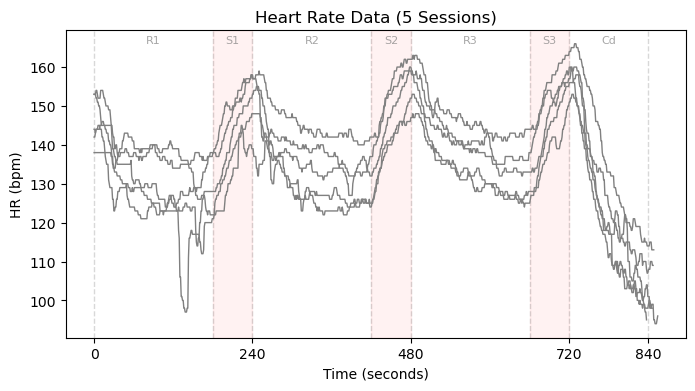

In [17]:
report.plot_raw_data()

# B-Splines

/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:84: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  # Convert Time to seconds
/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:84: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  # Convert Time to seconds
/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:84: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  # Convert Time to seconds
/Users/olgert.denas/code/interval_runs_analysis/bspline_model.py:84: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  # Conv

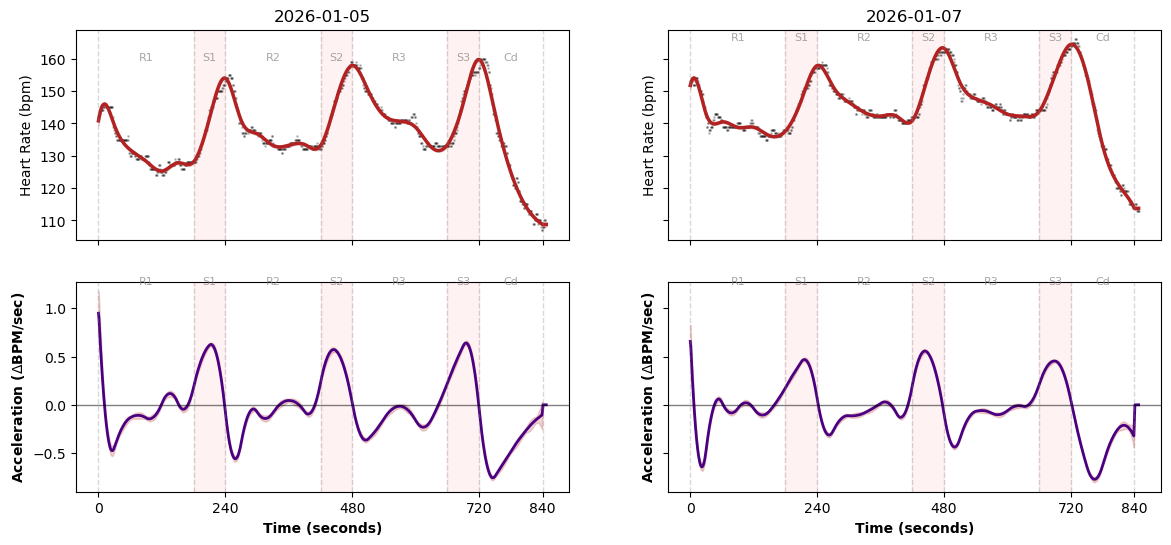

In [19]:
fig, axes = plt.subplots(ncols=len(report.sessions)-3, nrows=2, figsize=(14, 6), sharex=True, sharey='row')
report.plot_fit_accel(fig, axes)

/opt/homebrew/Caskroom/miniconda/base/envs/data-sci/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/data-sci/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/data-sci/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)


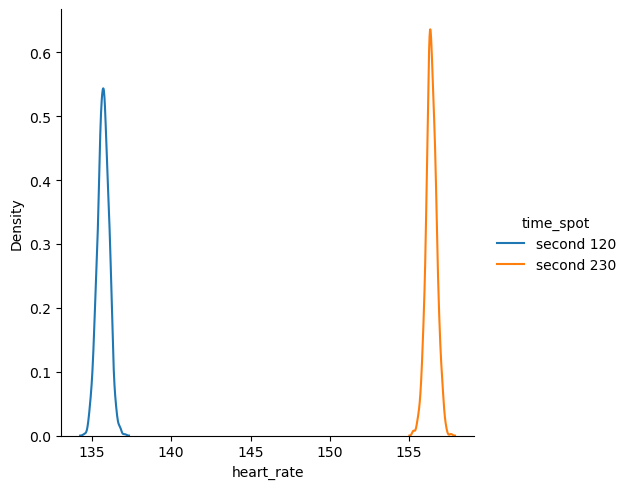

In [20]:
ex_session = report.sessions[0]
ex_time_spot1 = 120
ex_time_spot2 = 230
samples = ex_session.post_mu.shape[0]
sns.displot(data=pd.DataFrame(
    {
        'heart_rate': np.concatenate([ex_session.post_mu[:,ex_time_spot1], ex_session.post_mu[:,ex_time_spot2]]),
        'time_spot': ([f"second {ex_time_spot1}"] * samples) + ([f"second {ex_time_spot2}"] * samples)
    }

    ), x='heart_rate', hue='time_spot', kind='kde'
)

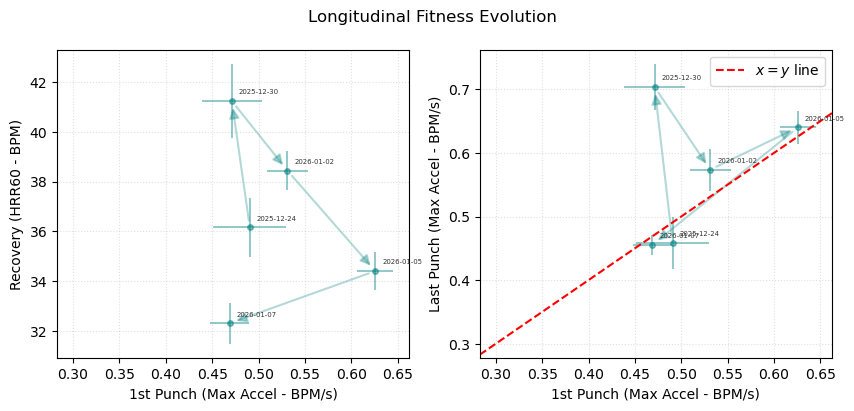

In [22]:
# report = TreadmillReport(standard_3x4, file_paths, False)
fig, ax_quad = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=False)
report.plot_trend_vector(fig, ax_quad[0], 'ph')
report.plot_trend_vector(fig, ax_quad[1], 'pp')
ax_quad[1].axline((0.3, 0.3), slope=1, color='r', linestyle='--', label='$x=y$ line'); ax_quad[1].legend()


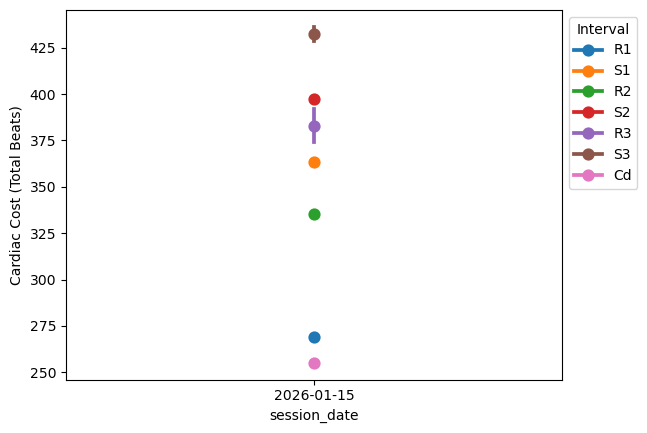

In [13]:
report.plot_cardiac_cost()